# Task 01: Data acquisition basics

**Authors** :
- name, first name, mtk
- name, first name, mtk 
- Hug, Victor, 2309471

Please put your code within the notebook python cells according to the template. 
The notebook is only used for questions requiring programming. If a question requires a screenshot or that you build a figure/sketch, this picture should be put within the report you submit. 

In [ ]:
# list your required libraries
from tqdm import tqdm
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import os
import scipy.io


     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------------- ------------ 41.0/60.8 kB 653.6 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 639.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/41.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/41.2 MB 3.3 MB/s eta 0:00:13
   ---------------------------------------- 0.5/41.2 MB 5.3 MB/s eta 0:00:08
   - -------------------------------------- 1.2/41.2 MB 8.2 MB/s eta 0:00:05
   - -------------------------------------- 1.9/41.2 MB 9.9 MB/s eta 0:00:04
   -- ------------------------------------- 2.4/41.2 MB 10.2 MB/s eta 0:00:04
   --- ------------------------------------ 3.2/41.2 MB 11.9 MB/s eta 0:00:04
   --- ------------------------------------ 3.6/41.2 MB 11.6 MB/s eta 0:00:04
   ---- ----------------------------------- 4.3/41.2 MB 12.5 MB/s eta 0:00:03
   --


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\EmilioBorrelli\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Answer to the questions

In general: one python cell for a question number.
The top of the python cell should contain a comment with the question number. 
For example 

```
# Question Q1

print('hello')
```

## Usage of Biopac

In [4]:
# Question Q1
# Load the exp02 data of the biopac

exp1_biopac = scipy.io.loadmat('data/assignment_1/ECG_PPG_1.mat')
exp2_biopac = scipy.io.loadmat('data/assignment_1/ECG_PPG_2.mat')

In [22]:
exp1_biopac['labels']

array(['PPG, X, PPGED-R', 'ECG, X, RSPEC-R'], dtype='<U15')

In [34]:
ecg_1 = exp1_biopac['data'][:, 1]
ppg_1 = exp1_biopac['data'][:, 0]

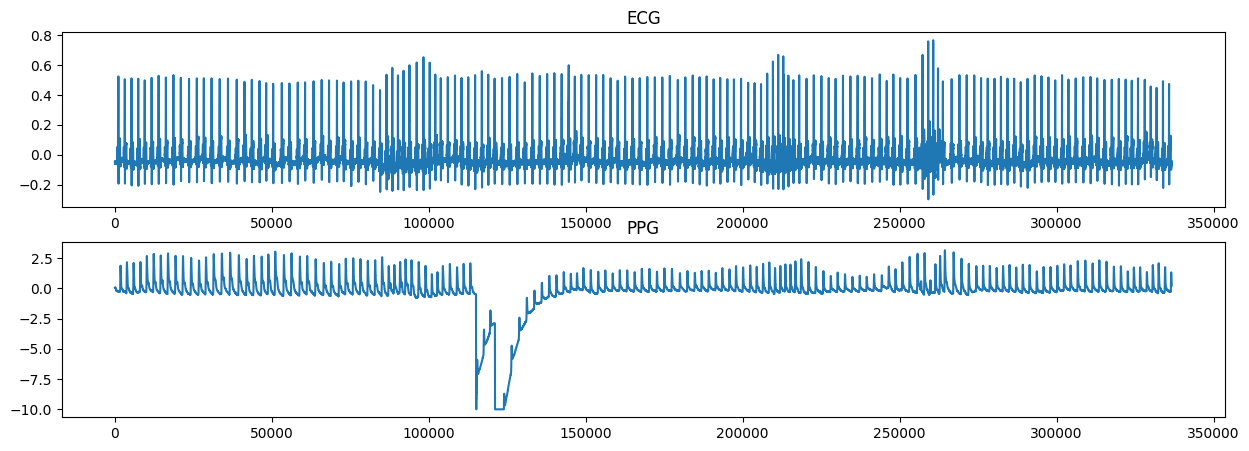

In [37]:
# Two Plots on top of each other with full curve
fig, ((ax1), (ax2)) = plt.subplots(2,1, figsize=(15, 5))
ax1.plot(ecg_1)
ax1.set_title('ECG')
ax2.plot(ppg_1)
ax2.set_title('PPG')
plt.show()

## Smartwatch

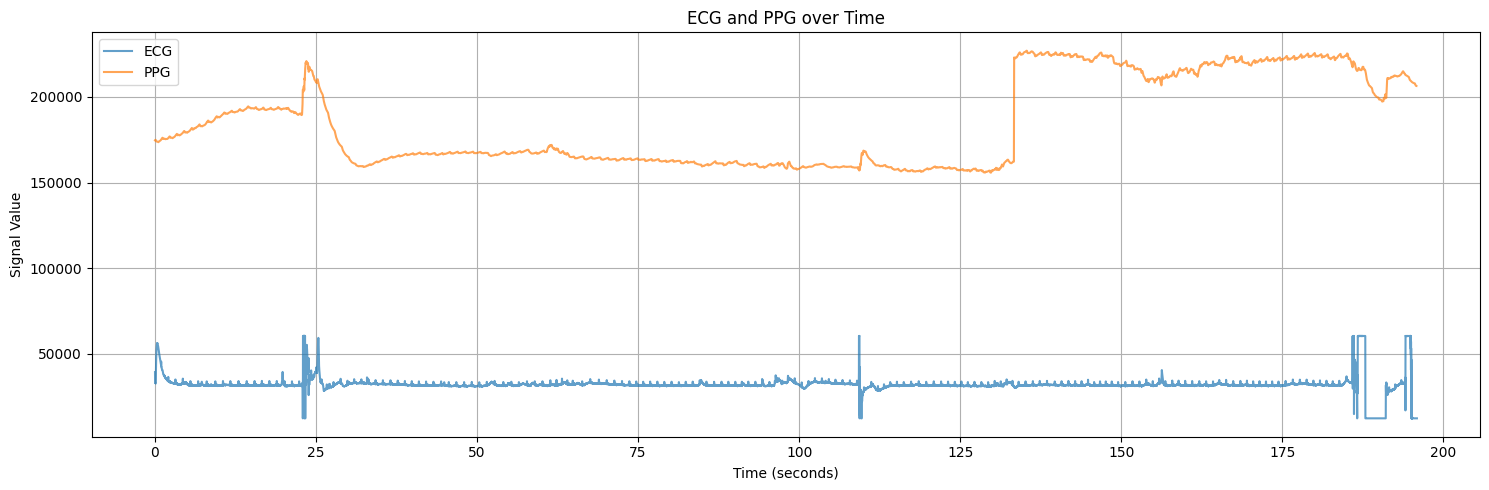

In [7]:
# Question Q3
ecg = pd.read_csv('data/assignment_2/ecg_2025_05_08_10_51_02ecgcentrifuge.csv', skiprows=2, engine='python')
ppg = pd.read_csv('data/assignment_2/ppg_2025_05_08_10_51_02ppgcentrifuge.csv', skiprows=2, engine='python')

# Clean column names
ecg.columns = ecg.columns.str.strip()
ppg.columns = ppg.columns.str.strip()

# Keep only relevant columns
ecg = ecg[['Timestamp', 'ECG data']].dropna()
ppg = ppg[['PPG Timestamp', 'PPG']].dropna()

# Convert to numbers
ecg['Timestamp'] = pd.to_numeric(ecg['Timestamp'], errors='coerce')
ecg['ECG data'] = pd.to_numeric(ecg['ECG data'], errors='coerce')
ppg['PPG Timestamp'] = pd.to_numeric(ppg['PPG Timestamp'], errors='coerce')
ppg['PPG'] = pd.to_numeric(ppg['PPG'], errors='coerce')

# Drop invalid rows
ecg = ecg.dropna()
ppg = ppg.dropna()

# Normalize time to start at 0 (in seconds)
ecg['time_sec'] = (ecg['Timestamp'] - ecg['Timestamp'].iloc[0]) / 1000
ppg['time_sec'] = (ppg['PPG Timestamp'] - ppg['PPG Timestamp'].iloc[0]) / 1000

plt.figure(figsize=(15, 5))

plt.plot(ecg['time_sec'], ecg['ECG data'], label='ECG', alpha=0.7)
plt.plot(ppg['time_sec'], ppg['PPG'], label='PPG', alpha=0.7)

plt.title("ECG and PPG over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



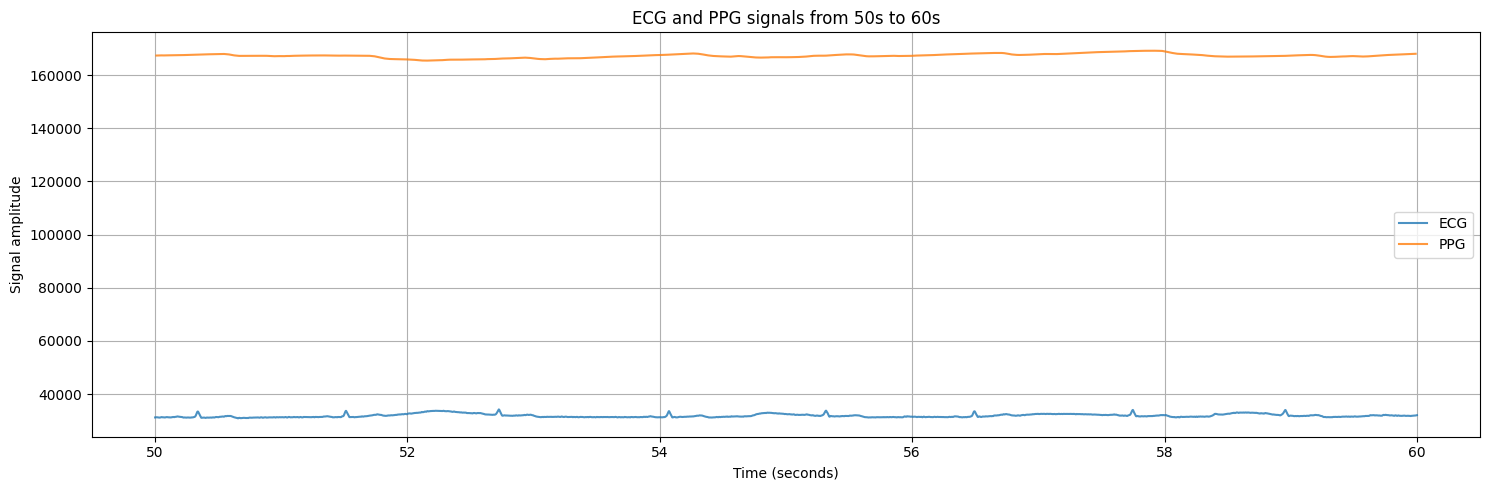

In [8]:
# Question Q4
# 1. Define time window manually (e.g., 20 to 30 seconds)
start_time = 50  # in seconds
end_time = 60    # 10 seconds later

# 2. Filter both signals
ecg_window = ecg[(ecg['time_sec'] >= start_time) & (ecg['time_sec'] <= end_time)]
ppg_window = ppg[(ppg['time_sec'] >= start_time) & (ppg['time_sec'] <= end_time)]

# 3. Plot both together
plt.figure(figsize=(15, 5))

plt.plot(ecg_window['time_sec'], ecg_window['ECG data'], label='ECG', alpha=0.8)
plt.plot(ppg_window['time_sec'], ppg_window['PPG'], label='PPG', alpha=0.8)

plt.title(f"ECG and PPG signals from {start_time}s to {end_time}s")
plt.xlabel("Time (seconds)")
plt.ylabel("Signal amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


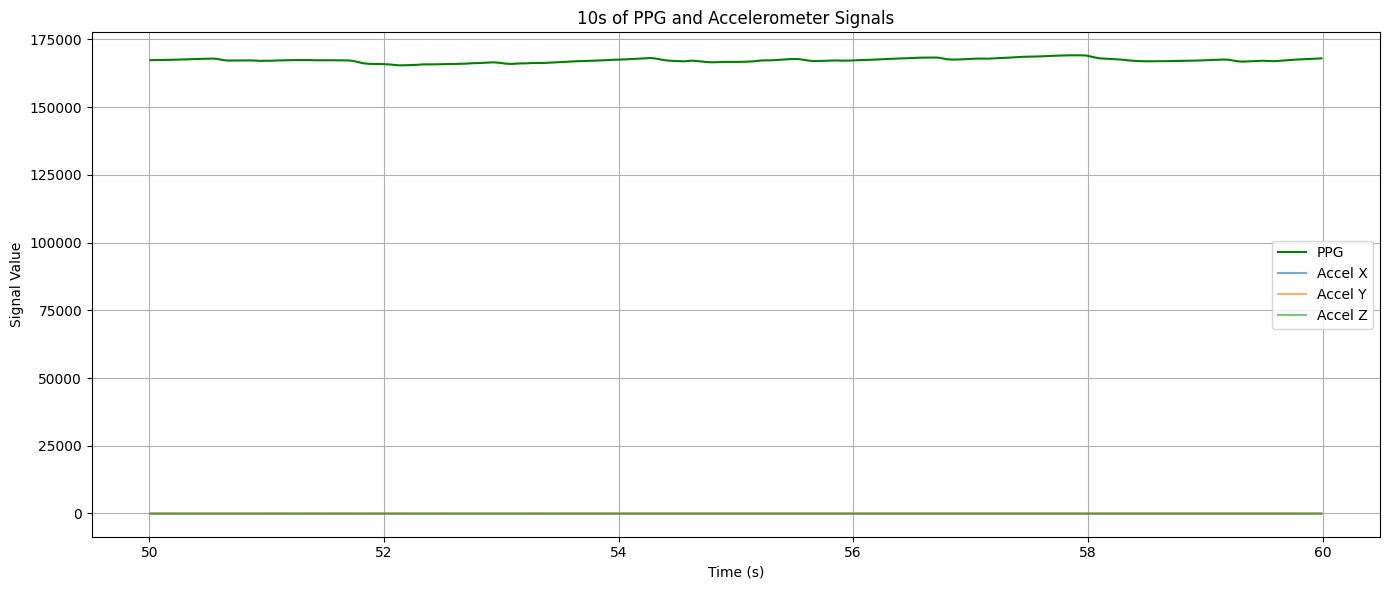

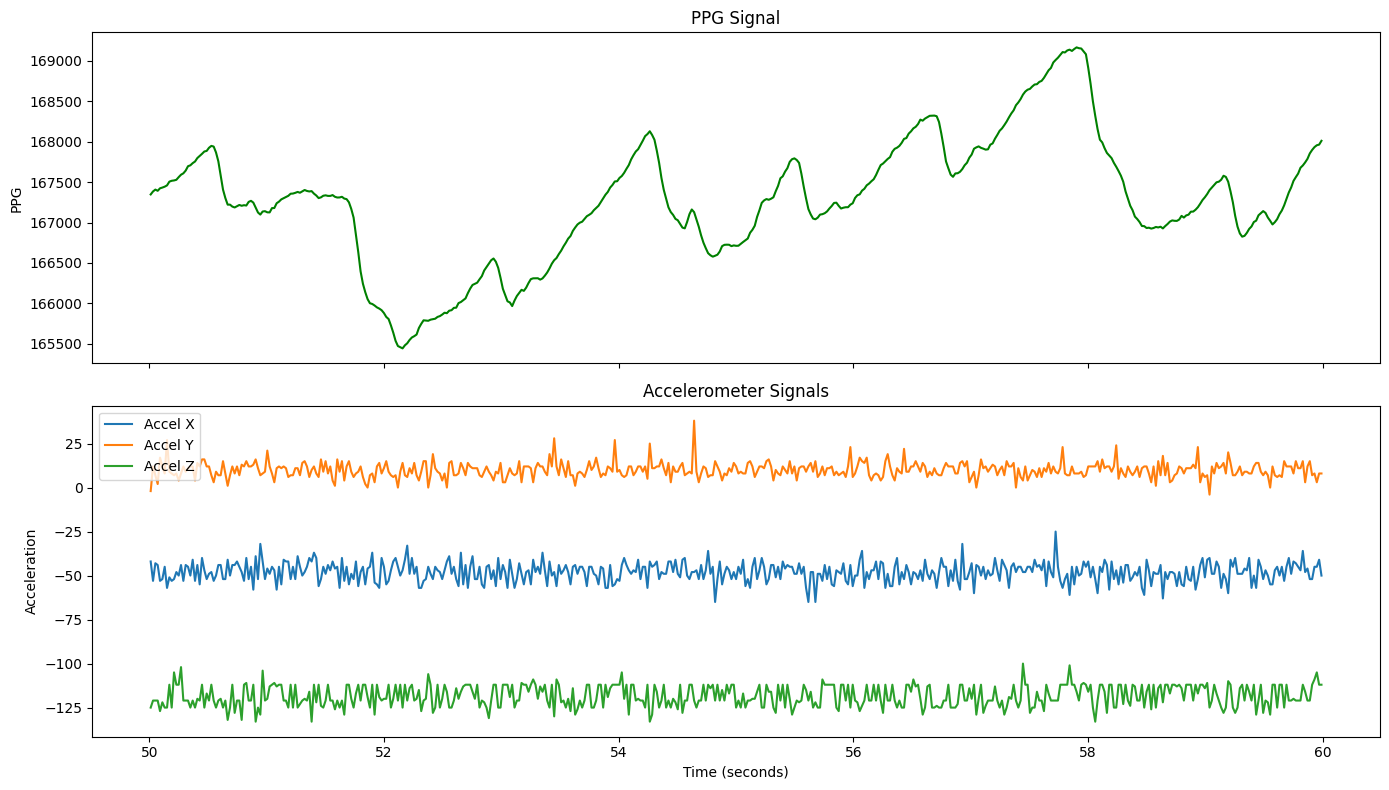

In [13]:
# Question Q5
df = pd.read_csv('data/assignment_2/ppg_2025_05_08_10_51_02ppgcentrifuge.csv', skiprows=2)

# Clean and convert
df = df[['PPG Timestamp', 'PPG', 'X', 'Y', 'Z']].dropna()
df['PPG Timestamp'] = pd.to_numeric(df['PPG Timestamp'], errors='coerce')
df = df.dropna()

# Convert to seconds
df['time_sec'] = (df['PPG Timestamp'] - df['PPG Timestamp'].iloc[0]) / 1000

# Select a 10s window (e.g., from 10s to 20s)
start = 50
end = start + 10
window = df[(df['time_sec'] >= start) & (df['time_sec'] <= end)]

# Plot PPG and accelerometer
plt.figure(figsize=(14, 6))

plt.plot(window['time_sec'], window['PPG'], label='PPG', color='green')
plt.plot(window['time_sec'], window['X'], label='Accel X', alpha=0.6)
plt.plot(window['time_sec'], window['Y'], label='Accel Y', alpha=0.6)
plt.plot(window['time_sec'], window['Z'], label='Accel Z', alpha=0.6)

plt.title("10s of PPG and Accelerometer Signals")
plt.xlabel("Time (s)")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Create figure and two vertically stacked subplots (shared x-axis)
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot PPG
axs[0].plot(window['time_sec'], window['PPG'], color='green')
axs[0].set_ylabel("PPG")
axs[0].set_title("PPG Signal")

# Plot Accelerometer X/Y/Z
axs[1].plot(window['time_sec'], window['X'], label='Accel X')
axs[1].plot(window['time_sec'], window['Y'], label='Accel Y')
axs[1].plot(window['time_sec'], window['Z'], label='Accel Z')
axs[1].set_ylabel("Acceleration")
axs[1].set_xlabel("Time (seconds)")
axs[1].set_title("Accelerometer Signals")
axs[1].legend()

plt.tight_layout()
plt.show()

Mean acceleration (approximate static gravity alignment):
X: -21.77 m/s²
Y: 14.60 m/s²
Z: -135.00 m/s²


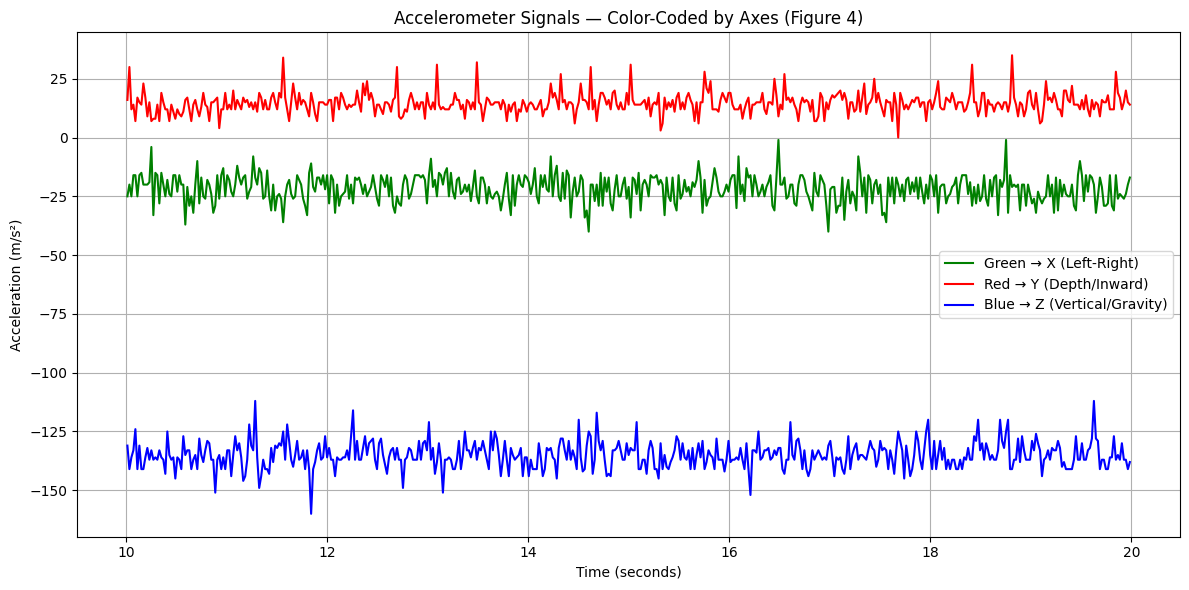

In [14]:
# Question Q6
# Load your data (adjust path if needed)
df = pd.read_csv('data/assignment_2/ppg_2025_05_08_10_51_02ppgcentrifuge.csv', skiprows=2)

# Keep only relevant columns
df = df[['PPG Timestamp', 'X', 'Y', 'Z']].dropna()

# Convert timestamp to seconds (relative)
df['PPG Timestamp'] = pd.to_numeric(df['PPG Timestamp'], errors='coerce')
df = df.dropna()
df['time_sec'] = (df['PPG Timestamp'] - df['PPG Timestamp'].iloc[0]) / 1000

# Select a 10-second still window (adjust as needed)
start = 10
end = 20
window = df[(df['time_sec'] >= start) & (df['time_sec'] <= end)]

# Calculate average acceleration on each axis
mean_x = window['X'].mean()
mean_y = window['Y'].mean()
mean_z = window['Z'].mean()

print("Mean acceleration (approximate static gravity alignment):")
print(f"X: {mean_x:.2f} m/s²")
print(f"Y: {mean_y:.2f} m/s²")
print(f"Z: {mean_z:.2f} m/s²")

# Plot axes with Figure 4's color coding:
# Green = horizontal (X), Red = depth (Y), Blue = vertical (Z)
plt.figure(figsize=(12, 6))

plt.plot(window['time_sec'], window['X'], color='green', label='Green → X (Left-Right)')
plt.plot(window['time_sec'], window['Y'], color='red', label='Red → Y (Depth/Inward)')
plt.plot(window['time_sec'], window['Z'], color='blue', label='Blue → Z (Vertical/Gravity)')

plt.title("Accelerometer Signals — Color-Coded by Axes (Figure 4)")
plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration (m/s²)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Temporal synchronization

In [ ]:
# Question Q8

In [ ]:
# Question Q9

In [ ]:
# Question Q11

In [ ]:
# Question Q12